In [1]:
# Load peristim matrix
from pathlib import Path
import numpy as np
import json
import RCP_analysis as rcp

%matplotlib inline
import matplotlib.pyplot as plt

PERTURB_VMIN = -100
PERTURB_VMAX = 100

# Paths
REPO_ROOT = Path().resolve().parents[1]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path("/media/bryan/Expansion") / Path("Nike/20260324_NRR_RW026")).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"

CONTROL_PERI_ROOT = PERI_ROOT / "control_reaches"
AT_REST_PERI_ROOT  = PERI_ROOT / "at_rest"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

INFERENCE_DATA = OUT_BASE / "checkpoints" / "inference"
INFERENCE_DATA.mkdir(parents=True, exist_ok=True)

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"

# FILE = 'peristim__NRR_RW_013_260129_134807__BR_001_target_A.npz'
# FILE = 'peristim__NRR_RW014_260130_163551__BR_106_target_A.npz'
FILE = 'peristim__NRR_RW026_260324_121810__BR_001.npz'

# Load control
control_dir = CONTROL_PERI_ROOT# / 'target_A'
control_npz_path = control_dir / FILE
control_npz = np.load(control_npz_path, allow_pickle=True)

In [2]:
# Load stim_ms
found_files = {}
files = []
stim_control_list = []
file_labels = []

stim_dir = STIM_PERI_ROOT# / 'target_A'

for file in stim_dir.glob("peristim__*.npz"):
    files.append(file)

stim_npz = np.load(file, allow_pickle=True)
stim_rel_t = stim_npz['NPRW_rel_t']
meta = json.loads(stim_npz['meta_json'].item())
stim_dur = meta["recording_stim_dur"]

In [3]:
# Redo control binning
NPRW_RATES = PARAMS.NPRW_rate_est
NPRW_BIN_MS     = NPRW_RATES.get("bin_ms")
NPRW_SIGMA_MS   = NPRW_RATES.get("sigma_ms")
NPRW_MS_BEFORE = float(NPRW_RATES.get("remove_ms_before"))
NPRW_TAIL_MS   = float(NPRW_RATES.get("remove_tail_ms_after"))
NPRW_DEDUP_MS = float(NPRW_RATES.get("dedup_ms", 0.5))
MAX_CLUSTER_MS = 0.5

WIN_MS            = (-600.0, 600.0)
NORMALIZE_FIRST_MS = 150.0

# dedup peaks
control_peak_ms_dedup = control_npz['NPRW_peak_ms_dedup']
if isinstance(control_peak_ms_dedup, np.ndarray) and control_peak_ms_dedup.dtype == object:
    control_peak_ms_dedup = control_peak_ms_dedup.item()
event_ms = control_npz['event_ms']

# bin ONLY for valid stims per stream
control_counts, control_rel_t, control_edges_ms, control_left_bins = rcp.bin_counts_around_stim(
    control_peak_ms_dedup, NPRW_BIN_MS, event_ms,
    NPRW_MS_BEFORE, (stim_dur + NPRW_TAIL_MS), WIN_MS
)
control_rates_hz = rcp.smooth_counts_gauss(control_counts, control_edges_ms, control_rel_t, NPRW_SIGMA_MS, control_left_bins)
control_rates_hz_baselined = rcp.baseline_zero_each_trial(control_rates_hz, control_rel_t, normalize_first_ms=NORMALIZE_FIRST_MS)


In [4]:
len(control_peak_ms_dedup)

128

In [5]:
BAD_MAP = rcp.get_session_impedances(SESSION_LOC)

In [6]:
# Bin post stim 29 is first one after stim
ROI = slice(29, 32)

control_rates = control_rates_hz_baselined[:, :, ROI].mean(axis=2)

In [7]:
stim_NPRW_list = []
stim_ind_list = []
stim_response_list = []
file_labels = []
sess_names = []
peak_signs = []
found_files = sorted(files)
    
# Session 13 file 2 weird
# Session 14 files 20
# Session 15 remove first file bad condition
# Session 26 remove 63th file because it's stim

for file_idx, file in enumerate(found_files):
    if file_idx == 62: #TODO Check
        continue
    with np.load(file, allow_pickle=True) as npz:
        stim_rates_zeroed = npz["NPRW_rates_zeroed"]
        nprw_meta = json.loads(npz["nprw_meta_json"].item())
        stim_ch_0 = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1
        sess_name = npz['sess']
        peak_sign = nprw_meta["peak_sign"]
        
    n_trials_i, n_ch, n_bins = stim_rates_zeroed.shape
    if n_ch != 128 or n_trials_i < 2 or n_bins == 53:
        print(f"SKIP file_idx={file_idx} (n_ch={n_ch}): {file}")
        continue
    
    stim_NPRW_list.append(stim_rates_zeroed)
    Si = np.zeros((n_trials_i, n_ch), dtype=np.uint8)
    Si[:, stim_ch_0] = 1
    
    trial_response = stim_rates_zeroed[:, :, ROI].mean(axis=2)

    stim_response_list.append(trial_response)
    stim_ind_list.append(Si)
    file_labels.extend([file_idx] * n_trials_i)
    sess_names.extend([str(sess_name)] * n_trials_i)
    peak_signs.extend([str(peak_sign)] * n_trials_i)

stim_NPRW_list_all_cond = np.concatenate(stim_NPRW_list, axis=0)
stim_ind_all_cond = np.concatenate(stim_ind_list, axis=0)
stim_response_all_cond = np.concatenate(stim_response_list, axis=0)
file_labels = np.asarray(file_labels, dtype=int)
sess_names_all_cond = np.asarray(sess_names, dtype=object)
peak_signs_all_cond = np.asarray(peak_signs, dtype=object)

print("Shape:", stim_NPRW_list_all_cond.shape)
print("Stim ind shape:", stim_ind_all_cond.shape)
print("Stim response shape:", stim_response_all_cond.shape)
print("#files:", len(stim_NPRW_list), "label shape:", file_labels.shape)
print("trials per file:", np.bincount(file_labels))
print("sess_names_all_cond shape:", sess_names_all_cond.shape)

SKIP file_idx=59 (n_ch=128): /media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_141917__BR_063.npz
Shape: (762, 128, 57)
Stim ind shape: (762, 128)
Stim response shape: (762, 128)
#files: 59 label shape: (762,)
trials per file: [11 12 12 12 16 12 12 14 12 13 14 12 13 14 15 13 13 13 13 12 12 12 12 12
 13 12 13 13 12 13 14 14 13 14 13 13 12 15 12 12 11 12 13 12 20 13 12 11
 13 13 13 12 13 13 13 13 11 16 14]
sess_names_all_cond shape: (762,)


np.int64(17)

In [8]:
from scipy.io import savemat

npz_path = INFERENCE_DATA / "session26_stim_inference_data.npz"

np.savez_compressed(
    npz_path,
    stim_rates=stim_NPRW_list_all_cond,        # (trials, ch, time)
    stim_indicator=stim_ind_all_cond,          # (trials, ch)
    stim_response=stim_response_all_cond,      # (trials, ch)
    file_labels=file_labels,                   # (trials,)
    control_rates=control_rates,         # (trials, ch)'
    time_bin_centers = control_rel_t,
    bin_dur= 20,
    stim_dur=stim_dur,
    artfact_remove_before=NPRW_MS_BEFORE,
    artfact_remove_after=NPRW_TAIL_MS,
    
)

# print(f"Saved NPZ → {npz_path}")

# mat_path = INFERENCE_DATA / "session26_stim_inference_data.mat"

# savemat(
#     mat_path,
#     {
#         "stim_rates": stim_NPRW_list_all_cond,
#         "stim_indicator": stim_ind_all_cond,
#         "stim_response": stim_response_all_cond,
#         "file_labels": file_labels,
#         "control_rates": control_rates,
#         "time_bin_centers": control_rel_t,
#         "bin_dur": 20,
#         "stim_dur":stim_dur,
#         "artfact_remove_before":NPRW_MS_BEFORE,
#         "artfact_remove_after":NPRW_TAIL_MS,
#     }
# )

# print(f"Saved MAT → {mat_path}")


In [9]:
sess_names_all_cond[230]

'NRR_RW026_260324_125055'

In [10]:
# npz_path_13 = "/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260129_NRR_RW013/results/checkpoints/inference/session13_stim_inference_data.npz"
# npz_path_14 = "/home/bryan/mnt/cullen_data/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260130_NRR_RW014/results/checkpoints/inference/session14_stim_inference_data.npz"
# npz_path_26 = "/media/bryan/Expansion/Nike/20260202_NRR_RW015/results/checkpoints/inference/session15_stim_inference_data.npz"
# npz_13 = np.load(npz_path_13)
# npz_14 = np.load(npz_path_14)
# npz_26 = np.load(npz_path_26)

npz_path_26 = INFERENCE_DATA / "session26_stim_inference_data.npz"
npz_26 = np.load(npz_path_26)

In [11]:
# Stratify into train test across files
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)

# stim_ind_13 = npz_13['stim_indicator']
# control_rates_mean_13 = npz_13['control_rates'].mean(axis=0)
# perturbation_13 = npz_13['stim_response'] - control_rates_mean_13[None, :]
# file_labels_13 = npz_13['file_labels']
# file_labels_13 = np.asarray(file_labels_13, dtype=int)
# train_idx_13, test_idx_13 = next(sss.split(np.zeros(len(file_labels_13)), file_labels_13))

# stim_ind_14 = npz_14['stim_indicator']
# control_rates_mean_14 = npz_14['control_rates'].mean(axis=0)
# perturbation_14 = npz_14['stim_response'] - control_rates_mean_14[None, :]
# file_labels_14 = npz_14['file_labels']
# file_labels_14 = np.asarray(file_labels_14, dtype=int)
# train_idx_14, test_idx_14 = next(sss.split(np.zeros(len(file_labels_14)), file_labels_14))

# stim_ind_15 = npz_15['stim_indicator']
# control_rates_mean_26 = npz_15['control_rates'].mean(axis=0)
# perturbation_15 = npz_15['stim_response'] - control_rates_mean_15[None, :]
# file_labels_15 = npz_15['file_labels']
# file_labels_15 = np.asarray(file_labels_15, dtype=int)
# train_idx_15, test_idx_15 = next(sss.split(np.zeros(len(file_labels_15)), file_labels_15))


stim_ind_26 = npz_26['stim_indicator']
control_rates_mean_26 = npz_26['control_rates'].mean(axis=0)
perturbation_26 = npz_26['stim_response'] - control_rates_mean_26[None, :]
file_labels_26 = npz_26['file_labels']
file_labels_26 = np.asarray(file_labels_26, dtype=int)
train_idx_26, test_idx_26 = next(sss.split(np.zeros(len(file_labels_26)), file_labels_26))


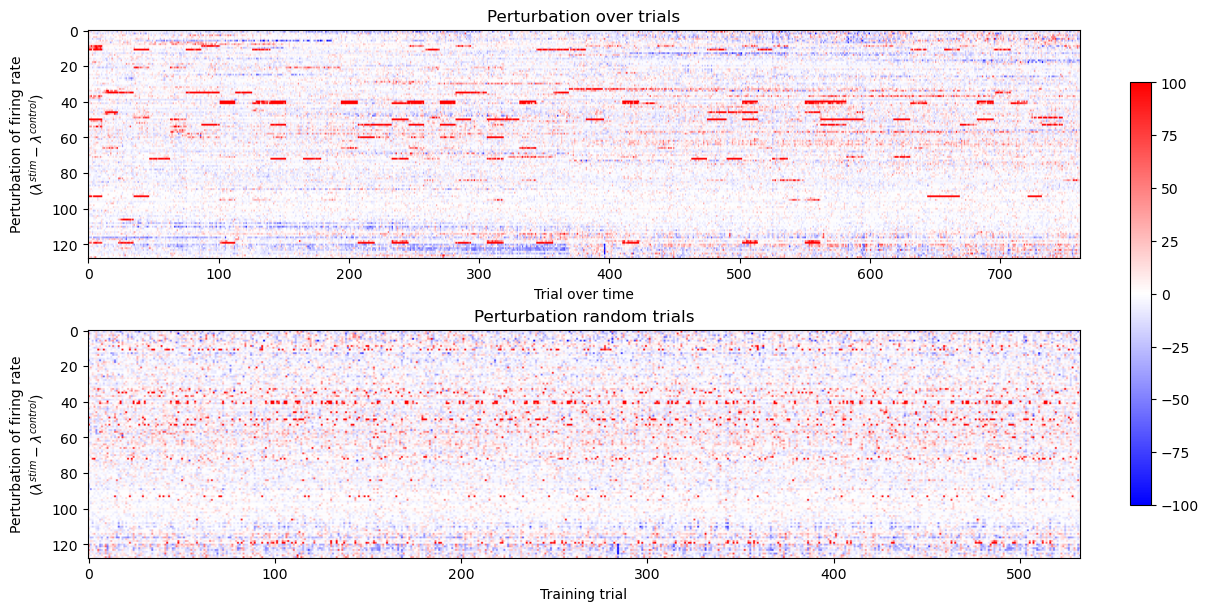

In [12]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    constrained_layout=True
)

# --- Full trials ---
im0 = axes[0].imshow(
    perturbation_26.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX
)
axes[0].set_xlabel("Trial over time")
axes[0].set_ylabel("Perturbation of firing rate\n($\\lambda^{stim}-\\lambda^{control}$)")
axes[0].set_title("Perturbation over trials")

# --- Training trials ---
im1 = axes[1].imshow(
    perturbation_26[train_idx_26].T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX
)
axes[1].set_xlabel("Training trial")
axes[1].set_ylabel("Perturbation of firing rate\n($\\lambda^{stim}-\\lambda^{control}$)")
axes[1].set_title("Perturbation random trials")

# Shared colorbar
fig.colorbar(im1, ax=axes, shrink=0.8)

plt.show()


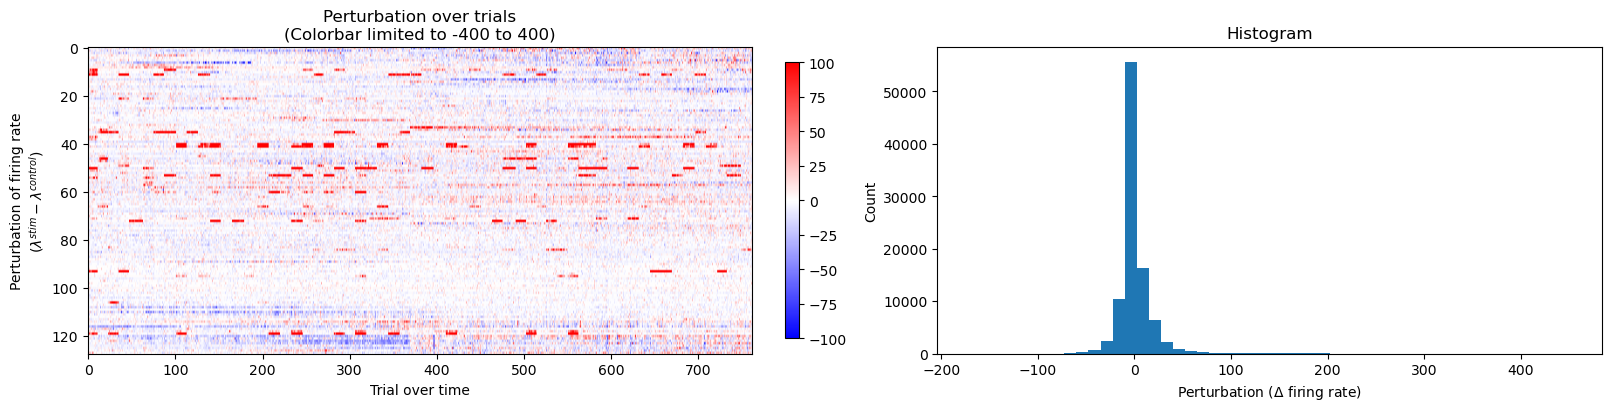

In [13]:
perturbation_26 = perturbation_26
vals = perturbation_26[np.isfinite(perturbation_26)].ravel()
absmax = np.max(np.abs(vals))

n_400_plus = np.sum(vals >= 400)
n_total = vals.size
stim_total = int(np.sum(stim_ind_26))

fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)

im = axes[0].imshow(
    perturbation_26.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[0].set_title("Perturbation over trials\n(Colorbar limited to -400 to 400)")
axes[0].set_xlabel("Trial over time")
axes[0].set_ylabel("Perturbation of firing rate\n($\\lambda^{stim}-\\lambda^{control}$)")
fig.colorbar(im, ax=axes[0], shrink=0.9)

axes[1].hist(vals, bins=50)
axes[1].set_title("Histogram")
axes[1].set_xlabel("Perturbation ($\\Delta$ firing rate)")
axes[1].set_ylabel("Count")

plt.show()

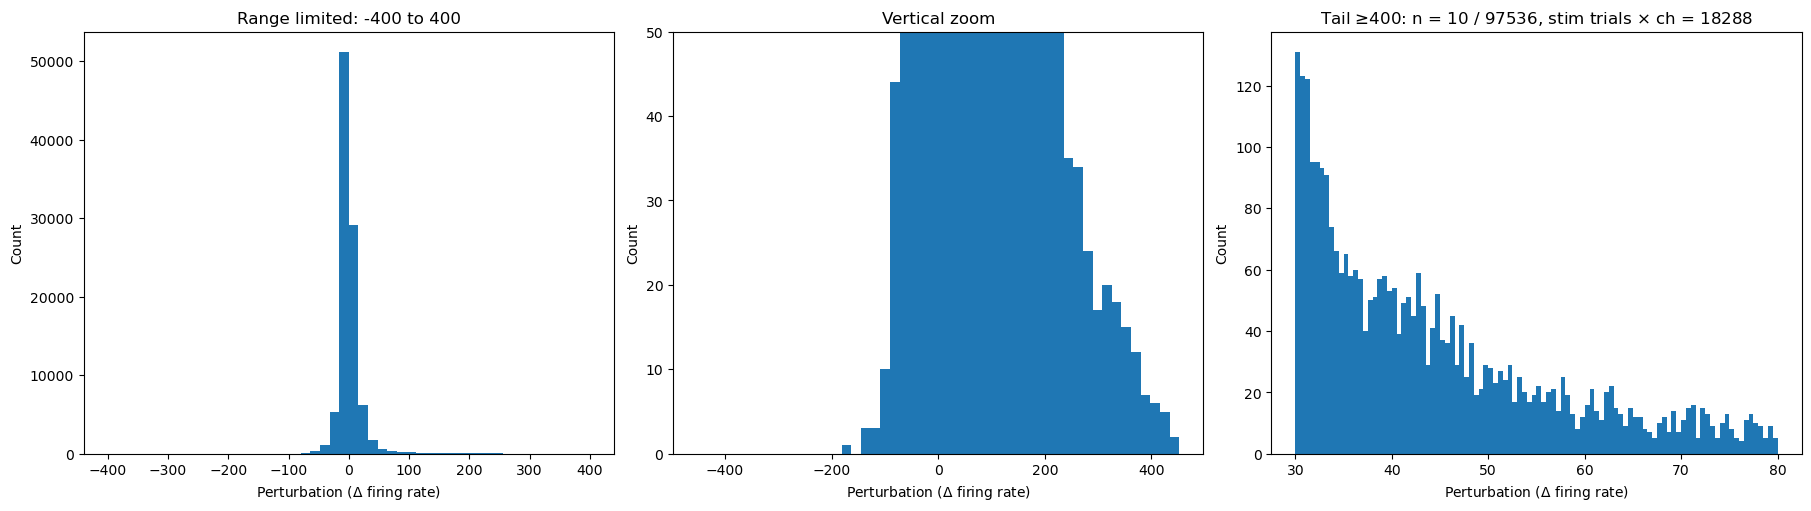

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].hist(vals, bins=50, range=(-400, 400))
axes[0].set_xlabel("Perturbation ($\\Delta$ firing rate)")
axes[0].set_ylabel("Count")
axes[0].set_title("Range limited: -400 to 400")

axes[1].hist(vals, bins=50, range=(-absmax, absmax))
axes[1].set_xlabel("Perturbation ($\\Delta$ firing rate)")
axes[1].set_ylabel("Count")
axes[1].set_title("Vertical zoom")
axes[1].set_ylim(0, 50)

axes[2].hist(vals, bins=100, range=(30, 80))
axes[2].set_xlabel("Perturbation ($\\Delta$ firing rate)")
axes[2].set_ylabel("Count")
axes[2].set_title(rf"Tail ≥400: n = {n_400_plus} / {n_total}, stim trials $\times$ ch = {stim_total}")

plt.show()

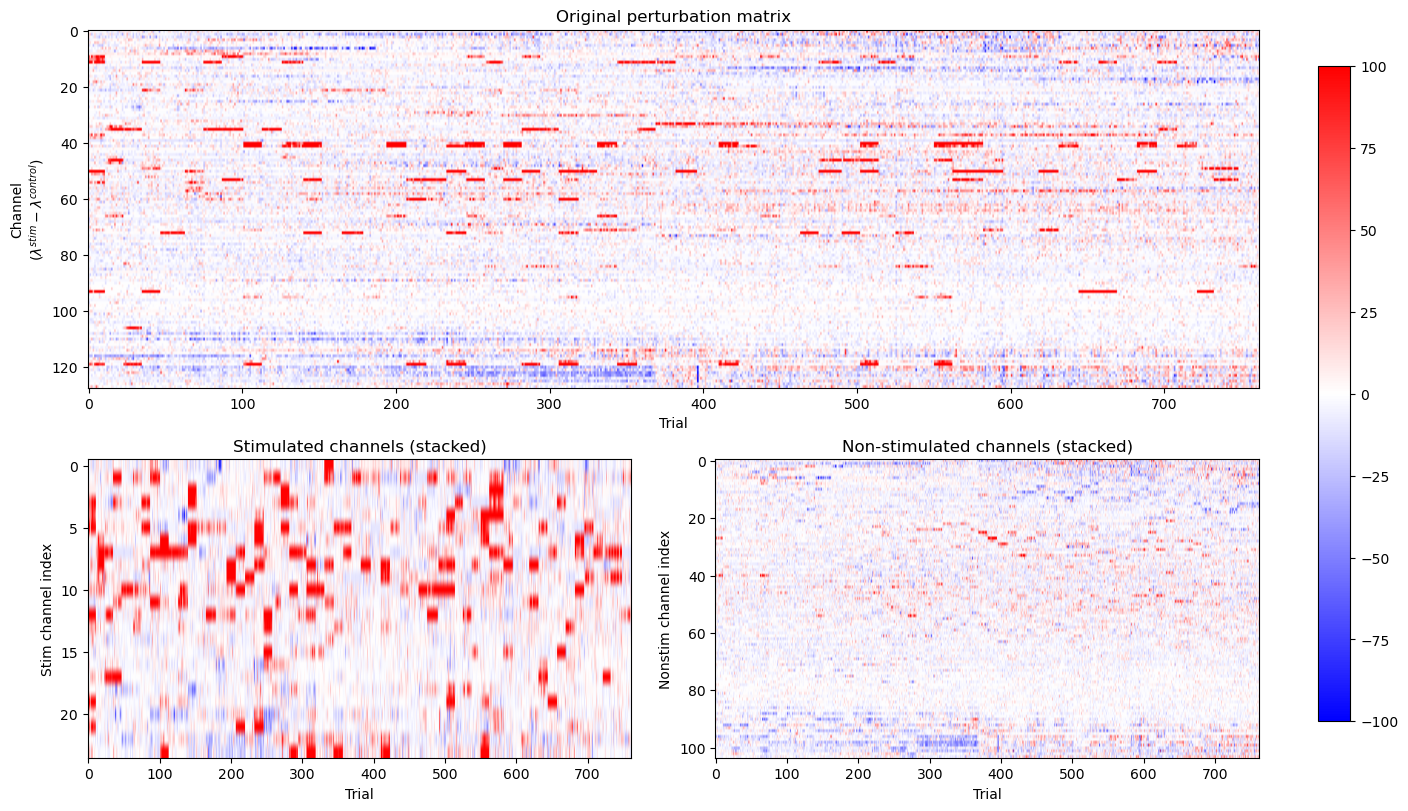

In [15]:
stim_list = []
nonstim_list = []

for t in range(perturbation_26.shape[0]):
    stim_idx = stim_ind_26[t] > 0
    nonstim_idx = ~stim_idx
    stim_list.append(perturbation_26[t, stim_idx])
    nonstim_list.append(perturbation_26[t, nonstim_idx])

Y_stim_stack = np.vstack(stim_list)
Y_nonstim_stack = np.vstack(nonstim_list)

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1.0])

ax0 = fig.add_subplot(gs[0, :])
im0 = ax0.imshow(
    perturbation_26.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
ax0.set_title("Original perturbation matrix")
ax0.set_xlabel("Trial")
ax0.set_ylabel("Channel\n($\\lambda^{stim}-\\lambda^{control}$)")

ax1 = fig.add_subplot(gs[1, 0])
im1 = ax1.imshow(
    Y_stim_stack.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
ax1.set_title("Stimulated channels (stacked)")
ax1.set_xlabel("Trial")
ax1.set_ylabel("Stim channel index")

ax2 = fig.add_subplot(gs[1, 1])
im2 = ax2.imshow(
    Y_nonstim_stack.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
ax2.set_title("Non-stimulated channels (stacked)")
ax2.set_xlabel("Trial")
ax2.set_ylabel("Nonstim channel index")

fig.colorbar(im2, ax=[ax0, ax1, ax2], shrink=0.9)
plt.show()

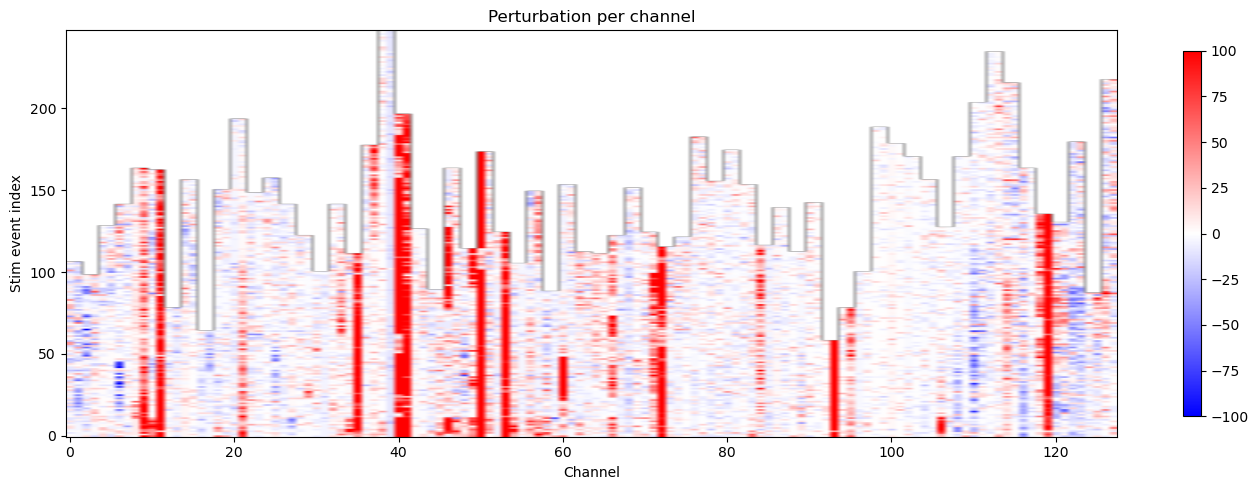

In [16]:
Y = perturbation_26
stim_ind_26 = stim_ind_26

seqs = []
counts = np.zeros(Y.shape[1], dtype=int)

for ch in range(Y.shape[1]):
    stim_trials = np.where(stim_ind_26[:, ch] > 0)[0]
    vals = Y[stim_trials, ch]
    seqs.append(vals)
    counts[ch] = vals.size

max_k = int(counts.max())

# Stack so rows = stim event index, columns = channel
Y_by_event = np.full((max_k, Y.shape[1]), np.nan)

for ch in range(Y.shape[1]):
    k = counts[ch]
    if k > 0:
        Y_by_event[:k, ch] = seqs[ch]

plt.figure(figsize=(14, 5))

im = plt.imshow(
    Y_by_event,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)

plt.title("Perturbation per channel")
plt.xlabel("Channel")
plt.ylabel("Stim event index")
plt.colorbar(im, shrink=0.9)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [17]:
class RobustPCA:
    def __init__(self, D, mu=None, lmbda=None):
        self.D = D
        self.S = np.zeros(self.D.shape)
        self.Y = np.zeros(self.D.shape)

        if mu is not None:
            self.mu = mu
        else:
            self.mu = np.prod(self.D.shape) / (4 * np.linalg.norm(self.D.flatten(), ord=1))

        self.mu_inv = 1 / self.mu

        if lmbda is not None:
            self.lmbda = lmbda
        else:
            self.lmbda = 1 / np.sqrt(np.max(self.D.shape))

    @staticmethod
    def frobenius_norm(M):
        return np.linalg.norm(M, ord='fro')

    @staticmethod
    def shrink(M, tau):
        return np.sign(M) * np.maximum(np.abs(M) - tau, 0)

    def svd_threshold(self, M, tau):
        U, S, V = np.linalg.svd(M, full_matrices=False)
        return np.dot(U, np.dot(np.diag(self.shrink(S, tau)), V))

    def fit(self, tol=None, max_iter=1000, iter_print=100):
        n_iter = 0
        err = np.inf
        Sk = self.S
        Yk = self.Y
        Lk = np.zeros(self.D.shape)

        if tol is not None:
            _tol = tol
        else:
            _tol = 1E-7 * self.frobenius_norm(self.D)

        # Principal Component Pursuit by Alternating Directions (ADMM)
        # Algorithm 1 from Candès et al., 2011 (https://dl.acm.org/doi/10.1145/1970392.1970395)
        while err > _tol and n_iter < max_iter:
            Lk = self.svd_threshold(
                self.D - Sk + self.mu_inv * Yk, self.mu_inv)                            #this line implements step 3
            Sk = self.shrink(
                self.D - Lk + self.mu_inv * Yk, self.lmbda * self.mu_inv)               #this line implements step 4
            Yk = Yk + self.mu * (self.D - Lk - Sk)                                      #this line implements step 5
            err = self.frobenius_norm(self.D - Lk - Sk)
            n_iter += 1
            if (n_iter % iter_print) == 0 or n_iter == 1 or n_iter > max_iter or err <= _tol:
                print(f'iteration: {n_iter}, error: {err}')

        self.L = Lk
        self.S = Sk
        return Lk, Sk

iteration: 1, error: 318.15834685164407
iteration: 100, error: 2.5319053497027397
iteration: 200, error: 1.132176825353186
iteration: 300, error: 0.18682035984157616
iteration: 400, error: 0.08942344491957113
iteration: 500, error: 0.05745810498034887


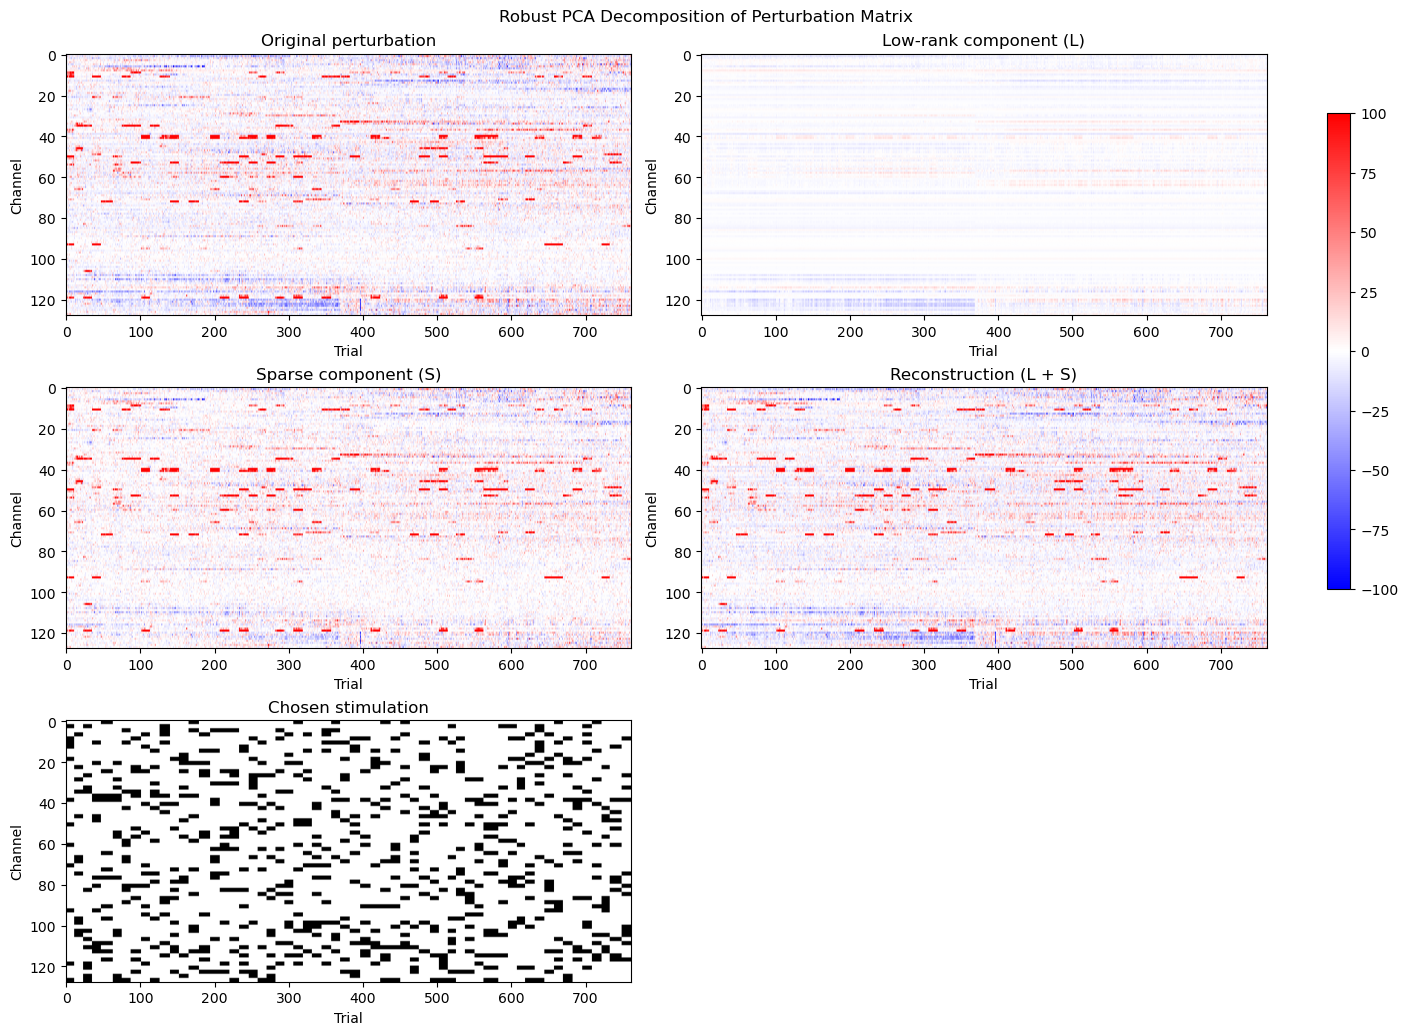

In [18]:
rpca = RobustPCA(perturbation_26)
L, S_sparse = rpca.fit(max_iter=500)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)

im0 = axes[0, 0].imshow(
    perturbation_26.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[0, 0].set_title("Original perturbation")
axes[0, 0].set_xlabel("Trial")
axes[0, 0].set_ylabel("Channel")

im1 = axes[0, 1].imshow(
    L.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[0, 1].set_title("Low-rank component (L)")
axes[0, 1].set_xlabel("Trial")
axes[0, 1].set_ylabel("Channel")

im2 = axes[1, 0].imshow(
    S_sparse.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[1, 0].set_title("Sparse component (S)")
axes[1, 0].set_xlabel("Trial")
axes[1, 0].set_ylabel("Channel")

im3 = axes[1, 1].imshow(
    (L + S_sparse).T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[1, 1].set_title("Reconstruction (L + S)")
axes[1, 1].set_xlabel("Trial")
axes[1, 1].set_ylabel("Channel")

im4 = axes[2, 0].imshow(
    stim_ind_26.T,
    aspect="auto",
    cmap="gray_r",
)
axes[2, 0].set_title("Chosen stimulation")
axes[2, 0].set_xlabel("Trial")
axes[2, 0].set_ylabel("Channel")

axes[2, 1].axis("off")

fig.suptitle("Robust PCA Decomposition of Perturbation Matrix", y=1.02)
fig.colorbar(im3, ax=axes[:2, :], shrink=0.8)

plt.show()

In [40]:
high_values = np.where(perturbation_26 > 200)

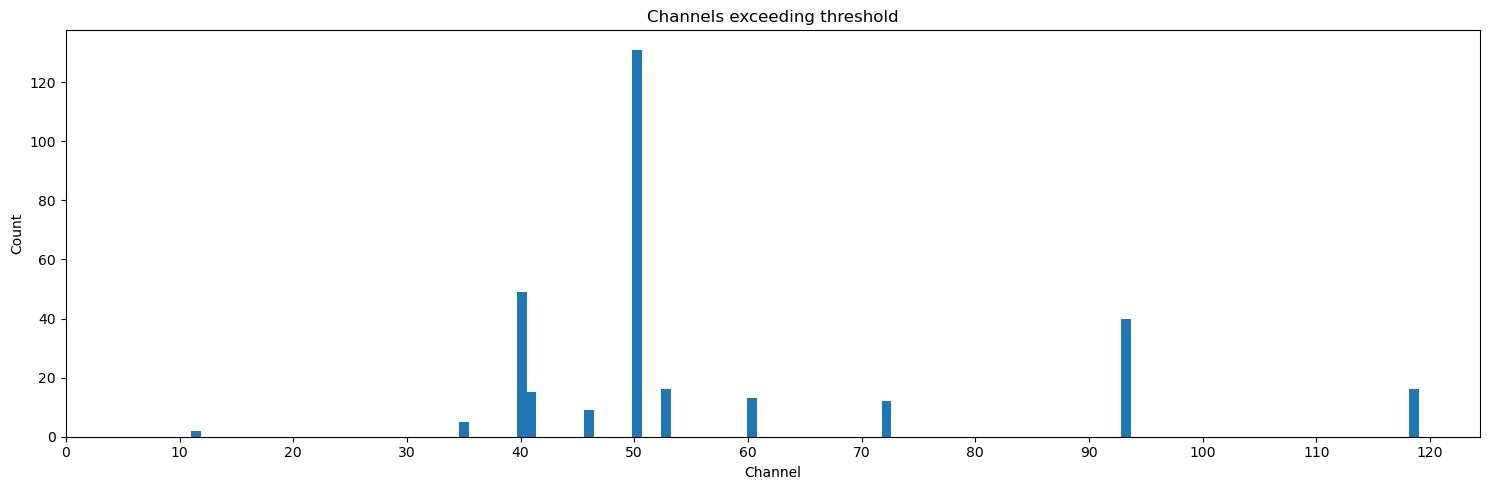

In [41]:
plt.figure(figsize=(15, 5))
plt.hist(high_values[1], bins=128)
plt.xticks(np.arange(0, 128, 10))
plt.xlabel("Channel")
plt.ylabel("Count")
plt.title("Channels exceeding threshold")
plt.tight_layout()
plt.show()

In [21]:
np.sort(high_values[1])

array([50, 50, 50, 50, 50, 50, 50, 50, 60, 93])

In [42]:
ch50_stim_trials = np.where(stim_ind_26[:, 50] == 1)
ch50_stim_trials

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10, 233, 234,
        235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 282, 283,
        284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 306, 307, 308,
        309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321,
        322, 323, 324, 325, 326, 327, 328, 329, 330, 382, 383, 384, 385,
        386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 475, 476, 477,
        478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 502,
        503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 537, 538,
        539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 562, 563,
        564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576,
        577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589,
        590, 591, 592, 593, 594, 618, 619, 620, 621, 622, 623, 624, 625,
        626, 627, 628, 629, 630, 682, 683, 684, 685, 686, 687, 688, 689,
        690, 691, 692, 693, 694]),)

In [45]:
file_labels[230], sess_names[233]

(np.int64(17), 'NRR_RW026_260324_125242')

In [24]:
# Load peristim matrix
from pathlib import Path
import RCP_analysis as rcp

%matplotlib inline
import matplotlib.pyplot as plt

INDEX = 22

# Paths
REPO_ROOT = Path().resolve().parents[1]
PARAMS = rcp.load_experiment_params(REPO_ROOT / "config" / "params.yaml", repo_root=REPO_ROOT)

SESSION_LOC = (Path("/media/bryan/Expansion") / Path("Nike/20260324_NRR_RW026")).resolve()
OUT_BASE = SESSION_LOC / "results"
OUT_BASE.mkdir(parents=True, exist_ok=True)

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)


/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_125550
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_125550__bin20ms_sigma20ms.npz


In [25]:
nprw_peaks_folder

PosixPath('/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_125550__bin20ms_sigma20ms.npz')

In [26]:
ALIGNED_CKPT_ROOT = OUT_BASE / "checkpoints" / "Aligned" / "stim_reaches"
aligned_files = sorted(ALIGNED_CKPT_ROOT.glob("aligned__*.npz"))
aligned_npz_path = aligned_files[INDEX]
print(aligned_npz_path)

aligned_npz = np.load(aligned_npz_path, allow_pickle=True)
nprw_peak_ms   = aligned_npz["nprw_peak_ms"].reshape(-1)[0]
nprw_peak_amps   = aligned_npz["nprw_peak_amps"].reshape(-1)[0]

ua_peak_ms   = aligned_npz["ua_peak_ms"].reshape(-1)[0]
ua_peak_amps   = aligned_npz["ua_peak_amps"].reshape(-1)[0]
ua_region = aligned_npz["ua_region"]
ua_region_names = aligned_npz["ua_region_names"]
ua_meta = aligned_npz["ua_meta"].item()
br_idx = int(nprw_meta['session'].split('_')[-1])


METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
SHIFTS_CSV    = METADATA_ROOT / "br_to_intan_shifts.csv"
br2shift_ms = rcp.get_metadata_mapping(SHIFTS_CSV, 'br_idx', 'shift_ms')
shift_ms = br2shift_ms.get(br_idx, None)



/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/Aligned/stim_reaches/aligned__NRR_RW026_260324_125906__Intan_025__BR_025.npz


In [27]:
nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_125550
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_125550__bin20ms_sigma20ms.npz


In [28]:
import spikeinterface as si
rec_nprw = si.load(nprw_pp_folder)
fs_nprw = float(rec_nprw.get_sampling_frequency())

print(rec_nprw)
print(f"Sampling rate: {fs_nprw:.1f} Hz")
print(f"Num channels: {rec_nprw.get_num_channels()}")
print(f"Duration: {rec_nprw.get_num_frames() / fs_nprw:.1f} s")

BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 2,231,040 samples 
                       74.37s (1.24 minutes) - int16 dtype - 544.69 MiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 74.4 s


In [29]:
def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

In [30]:
nprw_peaks_si_obj['peaks']

array([(    -29, 20, 2.31151104, 0), (    -29, 44, 1.13913822, 0),
       (    -29, 45, 2.13570261, 0), ..., (2231005, 23, 1.10801351, 0),
       (2231005, 25, 1.02540672, 0), (2231006, 24, 1.00869632, 0)],
      shape=(75750,), dtype=[('sample_index', '<i8'), ('channel_index', '<i8'), ('amplitude', '<f8'), ('segment_index', '<i8')])

In [31]:
# np.round(aligned_npz['stim_ms']-30+float(shift_ms)).astype(int)

In [32]:
shift_ms

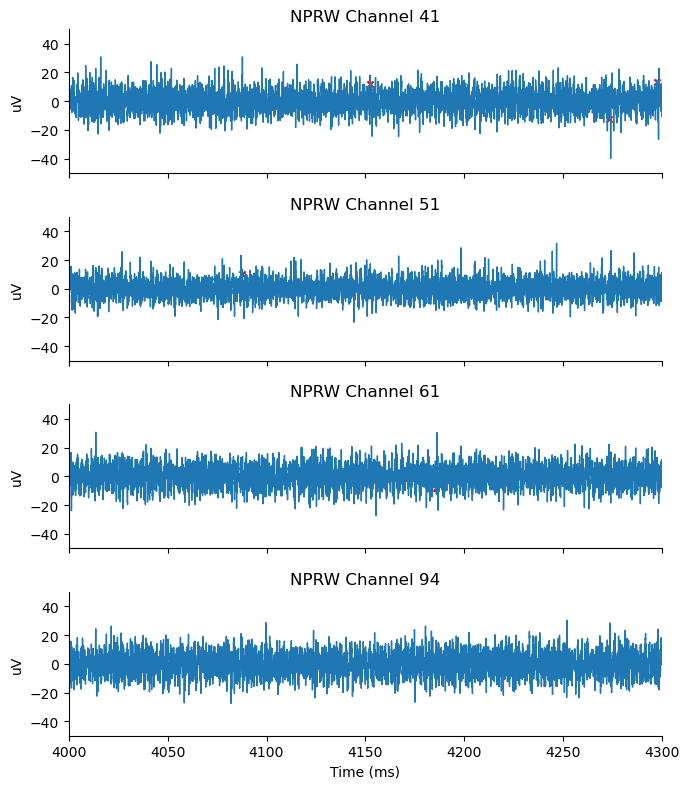

In [33]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

channels = [40, 50, 60, 93] #[9, 10, 11, 31, 32, 33]

T0_MS = 4000 # 3948, 8754, 12998, 18264, 22590, 45460, 50684, 55660, 60708, 65530, 70176, 76038
T1_MS = T0_MS + 300
PLOT_SHIFT = 3

fs = fs_nprw
rec = rec_nprw

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(channels), 1, figsize=(7, 3*len(channels)/1.5), sharex=True)

if len(channels) == 1:
    axes = [axes]

for ax, CH in zip(axes, channels):

    ch_id = rec.get_channel_ids()[CH]

    # Raw trace
    y = rec.get_traces(
        start_frame=i0,
        end_frame=i1,
        channel_ids=[ch_id],
        return_in_uV=True
    ).squeeze()

    t = (np.arange(i0, i1) / fs) * 1000.0

    # Peak samples
    pk_s = np.asarray(
        nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])),
        dtype=np.int64
    )

    # Keep peaks inside window
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]

    # Convert to window-relative indices
    pk_idx = (pk_s_w - i0).astype(int)

    # Convert to ms
    pk_ms_w = (pk_s_w / fs) * 1000.0

    # Sample amplitude directly from raw trace
    pk_y = y[pk_idx + PLOT_SHIFT]

    # Plot
    ax.plot(t, y, lw=1)

    if pk_ms_w.size:
        ax.scatter(
            pk_ms_w+PLOT_SHIFT/30,
            pk_y,
            s=20,
            marker="x",
            color="red"
        )

    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-50, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

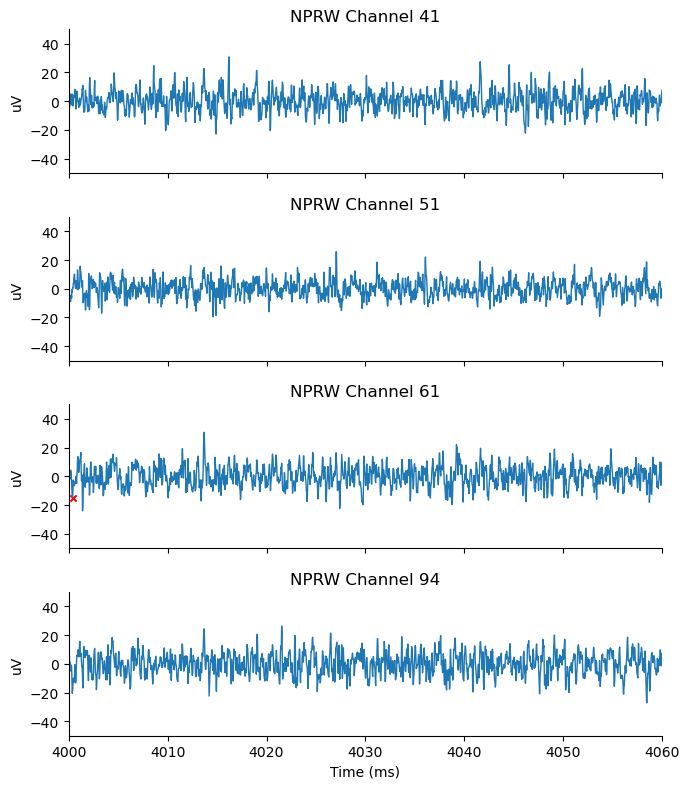

In [34]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

channels = [40, 50, 60, 93]#[40, 50, 60, 93]

T0_MS = 4000 # 3948, 8754, 12998, 18264, 22590, 45460, 50684, 55660, 60708, 65530, 70176, 76038
T1_MS = T0_MS + 60
PLOT_SHIFT = 0

fs = fs_nprw
rec = rec_nprw

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(channels), 1, figsize=(7, 3*len(channels)/1.5), sharex=True)

if len(channels) == 1:
    axes = [axes]

for ax, CH in zip(axes, channels):

    ch_id = rec.get_channel_ids()[CH]

    # Raw trace
    y = rec.get_traces(
        start_frame=i0,
        end_frame=i1,
        channel_ids=[ch_id],
        return_in_uV=True
    ).squeeze()

    t = (np.arange(i0, i1) / fs) * 1000.0

    # Peak samples
    pk_s = np.asarray(
        nprw_peak_samps.get(CH, nprw_peak_samps.get(np.int64(CH), [])),
        dtype=np.int64
    )

    # Keep peaks inside window
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]

    # Convert to window-relative indices
    pk_idx = (pk_s_w - i0).astype(int)

    # Convert to ms
    pk_ms_w = (pk_s_w / fs) * 1000.0

    # Sample amplitude directly from raw trace
    pk_y = y[pk_idx + PLOT_SHIFT]

    # Plot
    ax.plot(t, y, lw=1)

    if pk_ms_w.size:
        ax.scatter(
            pk_ms_w+PLOT_SHIFT/30,
            pk_y,
            s=20,
            marker="x",
            color="red"
        )

    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-50, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

In [35]:
import numpy as np

class RobustLowRankMapping:
    def __init__(self, Delta, S, tau=1.0, lam=1.0):
        """
        """
        self.Delta = Delta
        self.S = S
        self.tau = float(tau)
        self.lam = float(lam)

        n_ch = Delta.shape[0]
        self.W = np.zeros((n_ch, n_ch), dtype=float)
        self.E = np.zeros((n_ch, n_ch), dtype=float)

        # Spectral norm of S controls Lipschitz constant of gradient:
        # grad_{W,E} f = -2 (Delta - (W+E)S) S^T
        smax = np.linalg.svd(S, compute_uv=False, full_matrices=False)[0] # Get first singular value
        L = 2.0 * (smax ** 2 + 1e-12)
        self.step = 1.0 / L

    @staticmethod
    def frobenius_norm(M):
        return np.linalg.norm(M, ord='fro')

    @staticmethod
    def shrink(M, tau):
        return np.sign(M) * np.maximum(np.abs(M) - tau, 0)

    def svd_threshold(self, M, tau):
        U, S, V = np.linalg.svd(M, full_matrices=False)
        return np.dot(U, np.dot(np.diag(self.shrink(S, tau)), V))
    
    def fit(self, tol=None, max_iter=500, iter_print=100):
        W = self.W
        E = self.E
        S = self.S
        Delta = self.Delta
        step = self.step

        n_iter = 0
        err = np.inf
        
        if tol is not None:
            _tol = tol
        else:
            _tol = 1E-7 * self.frobenius_norm(self.Delta)

        while err > _tol and n_iter < max_iter:
            # Residual using (W+E)S
            residual = Delta - (W + E) @ S
            gradient = -2.0 * residual @ S.T

            # Proximal step for E
            E = self.shrink(E - step * gradient, step * self.lam)

            # Recompute residual after updating E
            residual = Delta - (W + E) @ S
            gradient = -2.0 * residual @ S.T

            # Proximal step for W
            W = self.svd_threshold(W - step * gradient, step * self.tau)

            err = self.frobenius_norm(Delta - (W + E) @ S)
            n_iter += 1
            if (n_iter % iter_print) == 0 or n_iter == 1 or err <= _tol:
                print(f"iteration: {n_iter}, error: {err:.3e}")

        self.W = W
        self.E = E
        return W, E

In [36]:
perturbation_26.shape

(762, 128)

In [37]:
Delta = perturbation_26.T
S = stim_ind_26.T

solver = RobustLowRankMapping(Delta, S, tau=0.1, lam=10)
W_hat, E_hat = solver.fit(max_iter=500)

WS = W_hat @ S
ES = E_hat @ S
Recon = (W_hat + E_hat) @ S

iteration: 1, error: 6.277e+03
iteration: 100, error: 4.026e+03
iteration: 200, error: 3.988e+03
iteration: 300, error: 3.975e+03
iteration: 400, error: 3.967e+03
iteration: 500, error: 3.961e+03


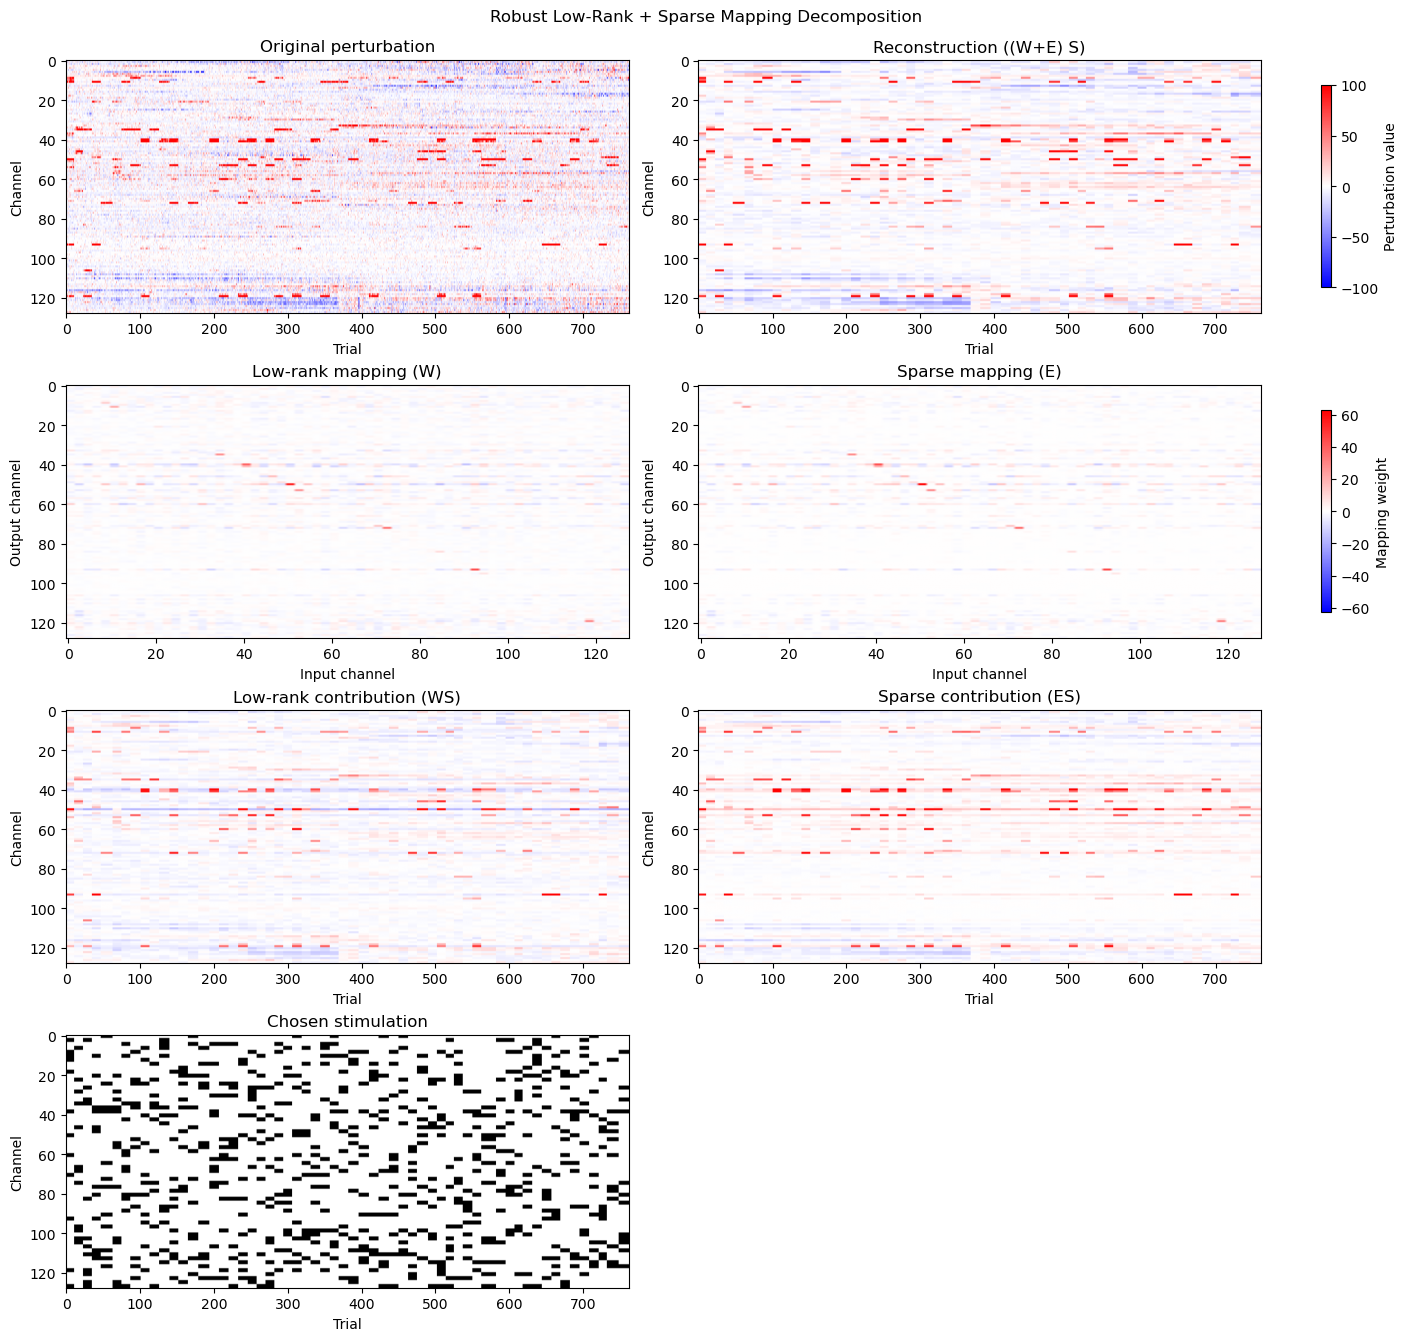

In [38]:
map_absmax = np.max(np.abs(np.concatenate([W_hat.flatten(), E_hat.flatten()])))

fig, axes = plt.subplots(4, 2, figsize=(14, 13), constrained_layout=True)

# Row 1 Data & Reconstruction
im0 = axes[0, 0].imshow(
    perturbation_26.T,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[0, 0].set_title("Original perturbation")
axes[0, 0].set_xlabel("Trial")
axes[0, 0].set_ylabel("Channel")

im1 = axes[0, 1].imshow(
    Recon,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[0, 1].set_title("Reconstruction ((W+E) S)")
axes[0, 1].set_xlabel("Trial")
axes[0, 1].set_ylabel("Channel")

# Row 2 - Mapping matrices
im2 = axes[1, 0].imshow(
    W_hat,
    aspect="auto",
    cmap="bwr",
    vmin=-map_absmax,
    vmax=map_absmax,
)
axes[1, 0].set_title("Low-rank mapping (W)")
axes[1, 0].set_xlabel("Input channel")
axes[1, 0].set_ylabel("Output channel")

im3 = axes[1, 1].imshow(
    E_hat,
    aspect="auto",
    cmap="bwr",
    vmin=-map_absmax,
    vmax=map_absmax,
)
axes[1, 1].set_title("Sparse mapping (E)")
axes[1, 1].set_xlabel("Input channel")
axes[1, 1].set_ylabel("Output channel")

# Row 3 — WS and ES
im4 = axes[2, 0].imshow(
    WS,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[2, 0].set_title("Low-rank contribution (WS)")
axes[2, 0].set_xlabel("Trial")
axes[2, 0].set_ylabel("Channel")

im5 = axes[2, 1].imshow(
    ES,
    aspect="auto",
    cmap="bwr",
    vmin=PERTURB_VMIN,
    vmax=PERTURB_VMAX,
)
axes[2, 1].set_title("Sparse contribution (ES)")
axes[2, 1].set_xlabel("Trial")
axes[2, 1].set_ylabel("Channel")

# Row 4 — Stimulation GT
im6 = axes[3, 0].imshow(
    stim_ind_26.T,
    aspect="auto",
    cmap="gray_r",
)
axes[3, 0].set_title("Chosen stimulation")
axes[3, 0].set_xlabel("Trial")
axes[3, 0].set_ylabel("Channel")

axes[3, 1].axis("off")

fig.suptitle("Robust Low-Rank + Sparse Mapping Decomposition", y=1.02)

# Colorbars
fig.colorbar(im1, ax=axes[0:1, :], shrink=0.8, label="Perturbation value")
fig.colorbar(im3, ax=axes[1, :], shrink=0.8, label="Mapping weight")

plt.show()

In [39]:
perturbation_26

array([[  2.31746832,   7.46236834,  11.9362433 , ...,  -9.67085367,
         -6.18902538,  -0.3350729 ],
       [ -0.70715645,  20.60560008,   3.2417818 , ...,  -2.97501391,
         -0.30500504,  16.54445069],
       [ -2.85967973, -21.67219488,  -1.77160721, ...,  -1.98938852,
         -0.22839734,  29.12848647],
       ...,
       [-10.19055645,  24.46620174, -19.62317113, ...,  19.41413487,
         -6.62059607,  28.87078012],
       [ 18.42998942,  33.3178933 , -10.63237411, ...,  13.16275058,
         -6.24611502,  -6.21097916],
       [-10.60113667,   4.50590567, -16.14440907, ...,  32.66121926,
          1.63479186,  42.40722013]], shape=(762, 128))